GMM in Python

In [8]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.datasets import load_wine
from sklearn.mixture import GaussianMixture
from sklearn.preprocessing import StandardScaler

Importo il dataset

In [9]:
data=load_wine()
X,y=data.data,data.target
target_names=data.target_names

Standarizzo

In [10]:
scaler=StandardScaler()
X_std=scaler.fit_transform(X)

Creo un oggetto PCA per la parte grafica (con due dimensioni visualizzo meglio)

In [11]:
pca=PCA(n_components=2,random_state=42)
X_pca=pca.fit_transform(X_std)

Non si usa la wcss inertica come in k-mean ma la log_likelihood

gmm.score dice quando il modello GMM riesce a spiegare bene i dati
Sono valori negativi che più si avvicinano allo 0 più sono buoni §(-1,1 meglio di -1,5)

In [61]:
bic_values=[]
aic_values=[]
scores=[]
k_values = range(1, 10)
for k in k_values:
        gmm = GaussianMixture(n_components=k, covariance_type='full', random_state=42)
        gmm.fit(X_std)
        bic_values.append(gmm.bic(X_std))
        aic_values.append(gmm.aic(X_std))
        scores.append(gmm.score(X_std))
print("k | score | improvement | AIC | BIC")
for i, (k, s, a, b) in enumerate(zip(k_values, scores, aic_values, bic_values)):
    if i == 0:
        improvement = 0 #non ha confronto
    else:
        improvement = s - scores[i-1]
    print(f"{k} | {s:.4f} | {improvement:.4f} | {a:.2f} | {b:.2f}")



k | score | improvement | AIC | BIC
1 | -14.6135 | 0.0000 | 5410.40 | 5741.30
2 | -12.7713 | 1.8422 | 4964.58 | 5629.57
3 | -11.8406 | 0.9307 | 4843.25 | 5842.33
4 | -10.2125 | 1.6281 | 4473.65 | 5806.82
5 | -10.5274 | -0.3149 | 4795.75 | 6463.00
6 | -10.1242 | 0.4032 | 4862.21 | 6863.55
7 | -8.7475 | 1.3767 | 4582.12 | 6917.55
8 | -5.7876 | 2.9599 | 3738.40 | 6407.92
9 | -4.3737 | 1.4139 | 3445.05 | 6448.66


c:\Users\uberti\.conda\envs\ai_epicode\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
c:\Users\uberti\.conda\envs\ai_epicode\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
c:\Users\uberti\.conda\envs\ai_epicode\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
c:\Users\uberti\.conda\envs\ai_epicode\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: User

Visivamene sembra che lo score migliora sempre, ma questo è ovvio che aumentando k il miglioramento, anche minimo, c'è sempre
E' come se ho 100 cluster e prendo k=100 in questo caso va in overfitting per generalizza troppo, avrei che ogni punto diventa un cluster

Quindi 
SCORE dice che è sempre meglio con più cluster, che il modello si adatta bene, ma va in overfitting
AIC dice che il modello, continua a migliorare all'aumentare di k, ma sta finendo in overfitting
BIC dice che il migiore k è 2, ho il bic minore


In [ ]:
log_likelihood = []
n_components = range(1, 10)
for k in n_components:
        gmm = GaussianMixture(n_components=k, covariance_type='full', random_state=42)
        gmm.fit(X_std)
        log_likelihood.append(gmm.score(X_std))
# Stampa con miglioramento
print("k | score | miglioramento")        
for i, k in enumerate(n_components):
    score = log_likelihood[i]
    if i == 0:
        improvement = 0  # primo non ha confronto
    else:
        improvement = score - log_likelihood[i-1]
    print(f"{k} | {score:.4f} | {improvement:.4f}")

k | score | miglioramento
1 | -14.6135 | 0.0000
2 | -12.7713 | 1.8422
3 | -11.8406 | 0.9307
4 | -10.2125 | 1.6281
5 | -10.5274 | -0.3149
6 | -10.1242 | 0.4032
7 | -8.7475 | 1.3767
8 | -5.7876 | 2.9599
9 | -4.3737 | 1.4139


c:\Users\uberti\.conda\envs\ai_epicode\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
c:\Users\uberti\.conda\envs\ai_epicode\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
c:\Users\uberti\.conda\envs\ai_epicode\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
c:\Users\uberti\.conda\envs\ai_epicode\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: User

Nella visualizzazione precedente fintanto che ho un grande miglioramento ha senso aumentare k, quando inizio ad avere piccoli miglioramenti sto solo aggiungendo complessità inutile (overfitting).
Se guardiamo k>=7 abbiamo ottimi miglioramenti, questo però indica che il modello GMM sta overfittando, pertanto probabilmente non è il più adatto per questo dataset.
Avevamo che DBSCAN consigliava k=2 anche silhoutte score consigliava k=2 quindi corretto dire che k=2 sembra essere la soluzione ottimanle ma non per il metodo GMM ma per dbscan e silhoutte

plotto

C:\Users\uberti\AppData\Local\Temp\ipykernel_37564\2706037797.py:7: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


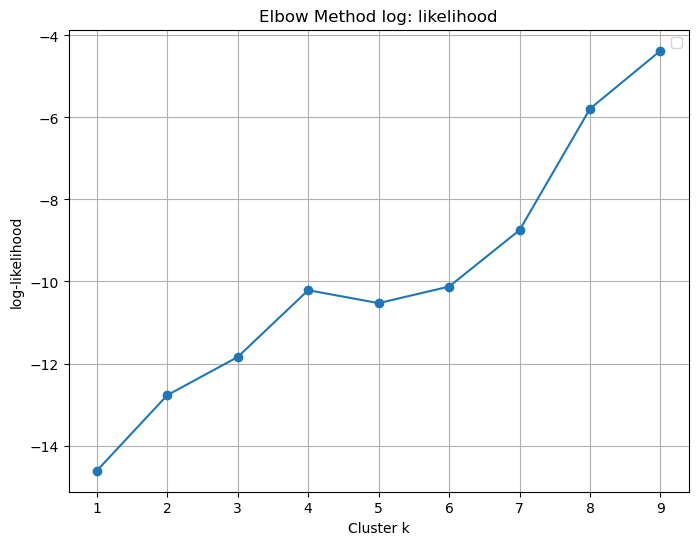

In [ ]:
plt.figure(figsize=(8,6))
plt.plot(n_components,log_likelihood[:1],marker='o')
plt.title("Elbow Method log: likelihood")
plt.xlabel("Cluster k")
plt.ylabel("log-likelihood")
plt.grid()
plt.legend()
plt.show()


In [15]:
best_k=3
gmm=GaussianMixture(n_components=best_k,covariance_type='full',random_state=42)
gmm.fit(X_std)
labels=gmm.predict(X_std)

print(labels.shape)
print(labels)

(178,)
[2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2
 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 0 0 1 0 0 0 0 0 0 0 0 0 0 0 2
 0 0 0 0 0 0 0 0 0 1 0 0 0 0 0 0 0 0 0 0 0 2 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 1 0 0 2 0 0 0 0 0 0 0 0 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1]


c:\Users\uberti\.conda\envs\ai_epicode\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


Vediamo come sono rappresentati i dati con queste labels

C:\Users\uberti\AppData\Local\Temp\ipykernel_37564\4125751829.py:7: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


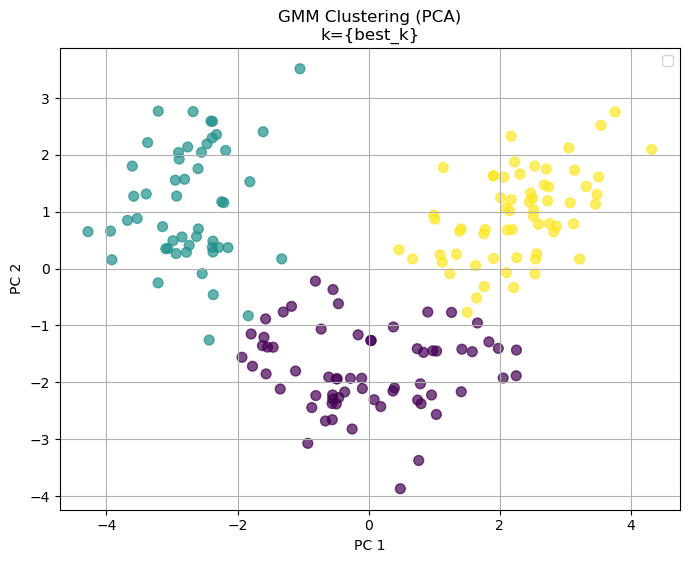

In [17]:
plt.figure(figsize=(8,6))
plt.scatter(X_pca[:,0],X_pca[:,1],c=labels,cmap='viridis',s=50,alpha=0.7)
plt.title("GMM Clustering (PCA)\nk={best_k}")
plt.xlabel("PC 1")
plt.ylabel("PC 2")
plt.grid()
plt.legend()
plt.show()

Vediamo correttamente le 3 label calcolato da GMM con colori diversi

Ora possiamo vedere come queste labels sono state predette

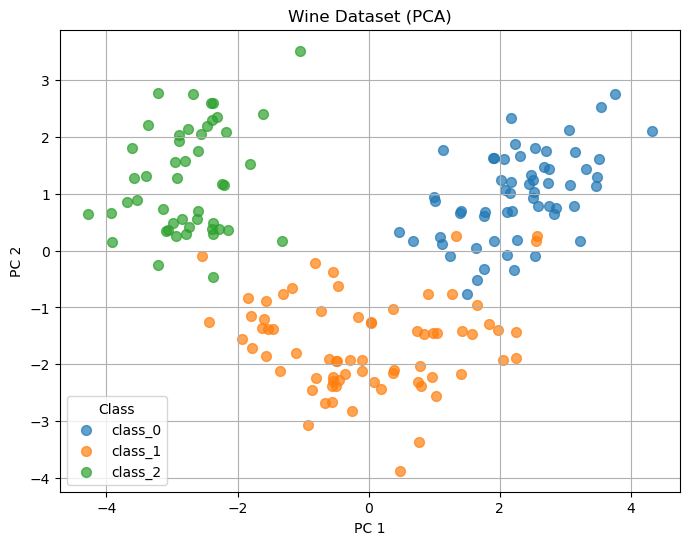

In [19]:
plt.figure(figsize=(8, 6))
for label in np.unique(y):
    mask = (y == label)
    plt.scatter(X_pca[mask, 0], X_pca[mask, 1], s=50, alpha=0.7, label=target_names[label])

plt.title("Wine Dataset (PCA)")
plt.xlabel("PC 1")
plt.ylabel("PC 2")
plt.legend(title="Class")
plt.grid()
plt.show()

In [49]:
def gmm_accurancy(y_true,y_pred):
    labels=np.zeros_like(y_pred)
    for cluster_id in np.unique(y_pred):
        mask=(cluster_id==y_pred)
        true_labels=y_true[mask]
        if true_labels.size>0:
            most_common=np.bincount(true_labels).argmax()
            labels[mask]=most_common
    return np.mean(labels==y_true)

In [51]:
accuracy=gmm_accurancy(y,labels)
print(f"GMM Clustering accurancy: {accuracy*100}%")

GMM Clustering accurancy: 96.62921348314607%
